Saved.


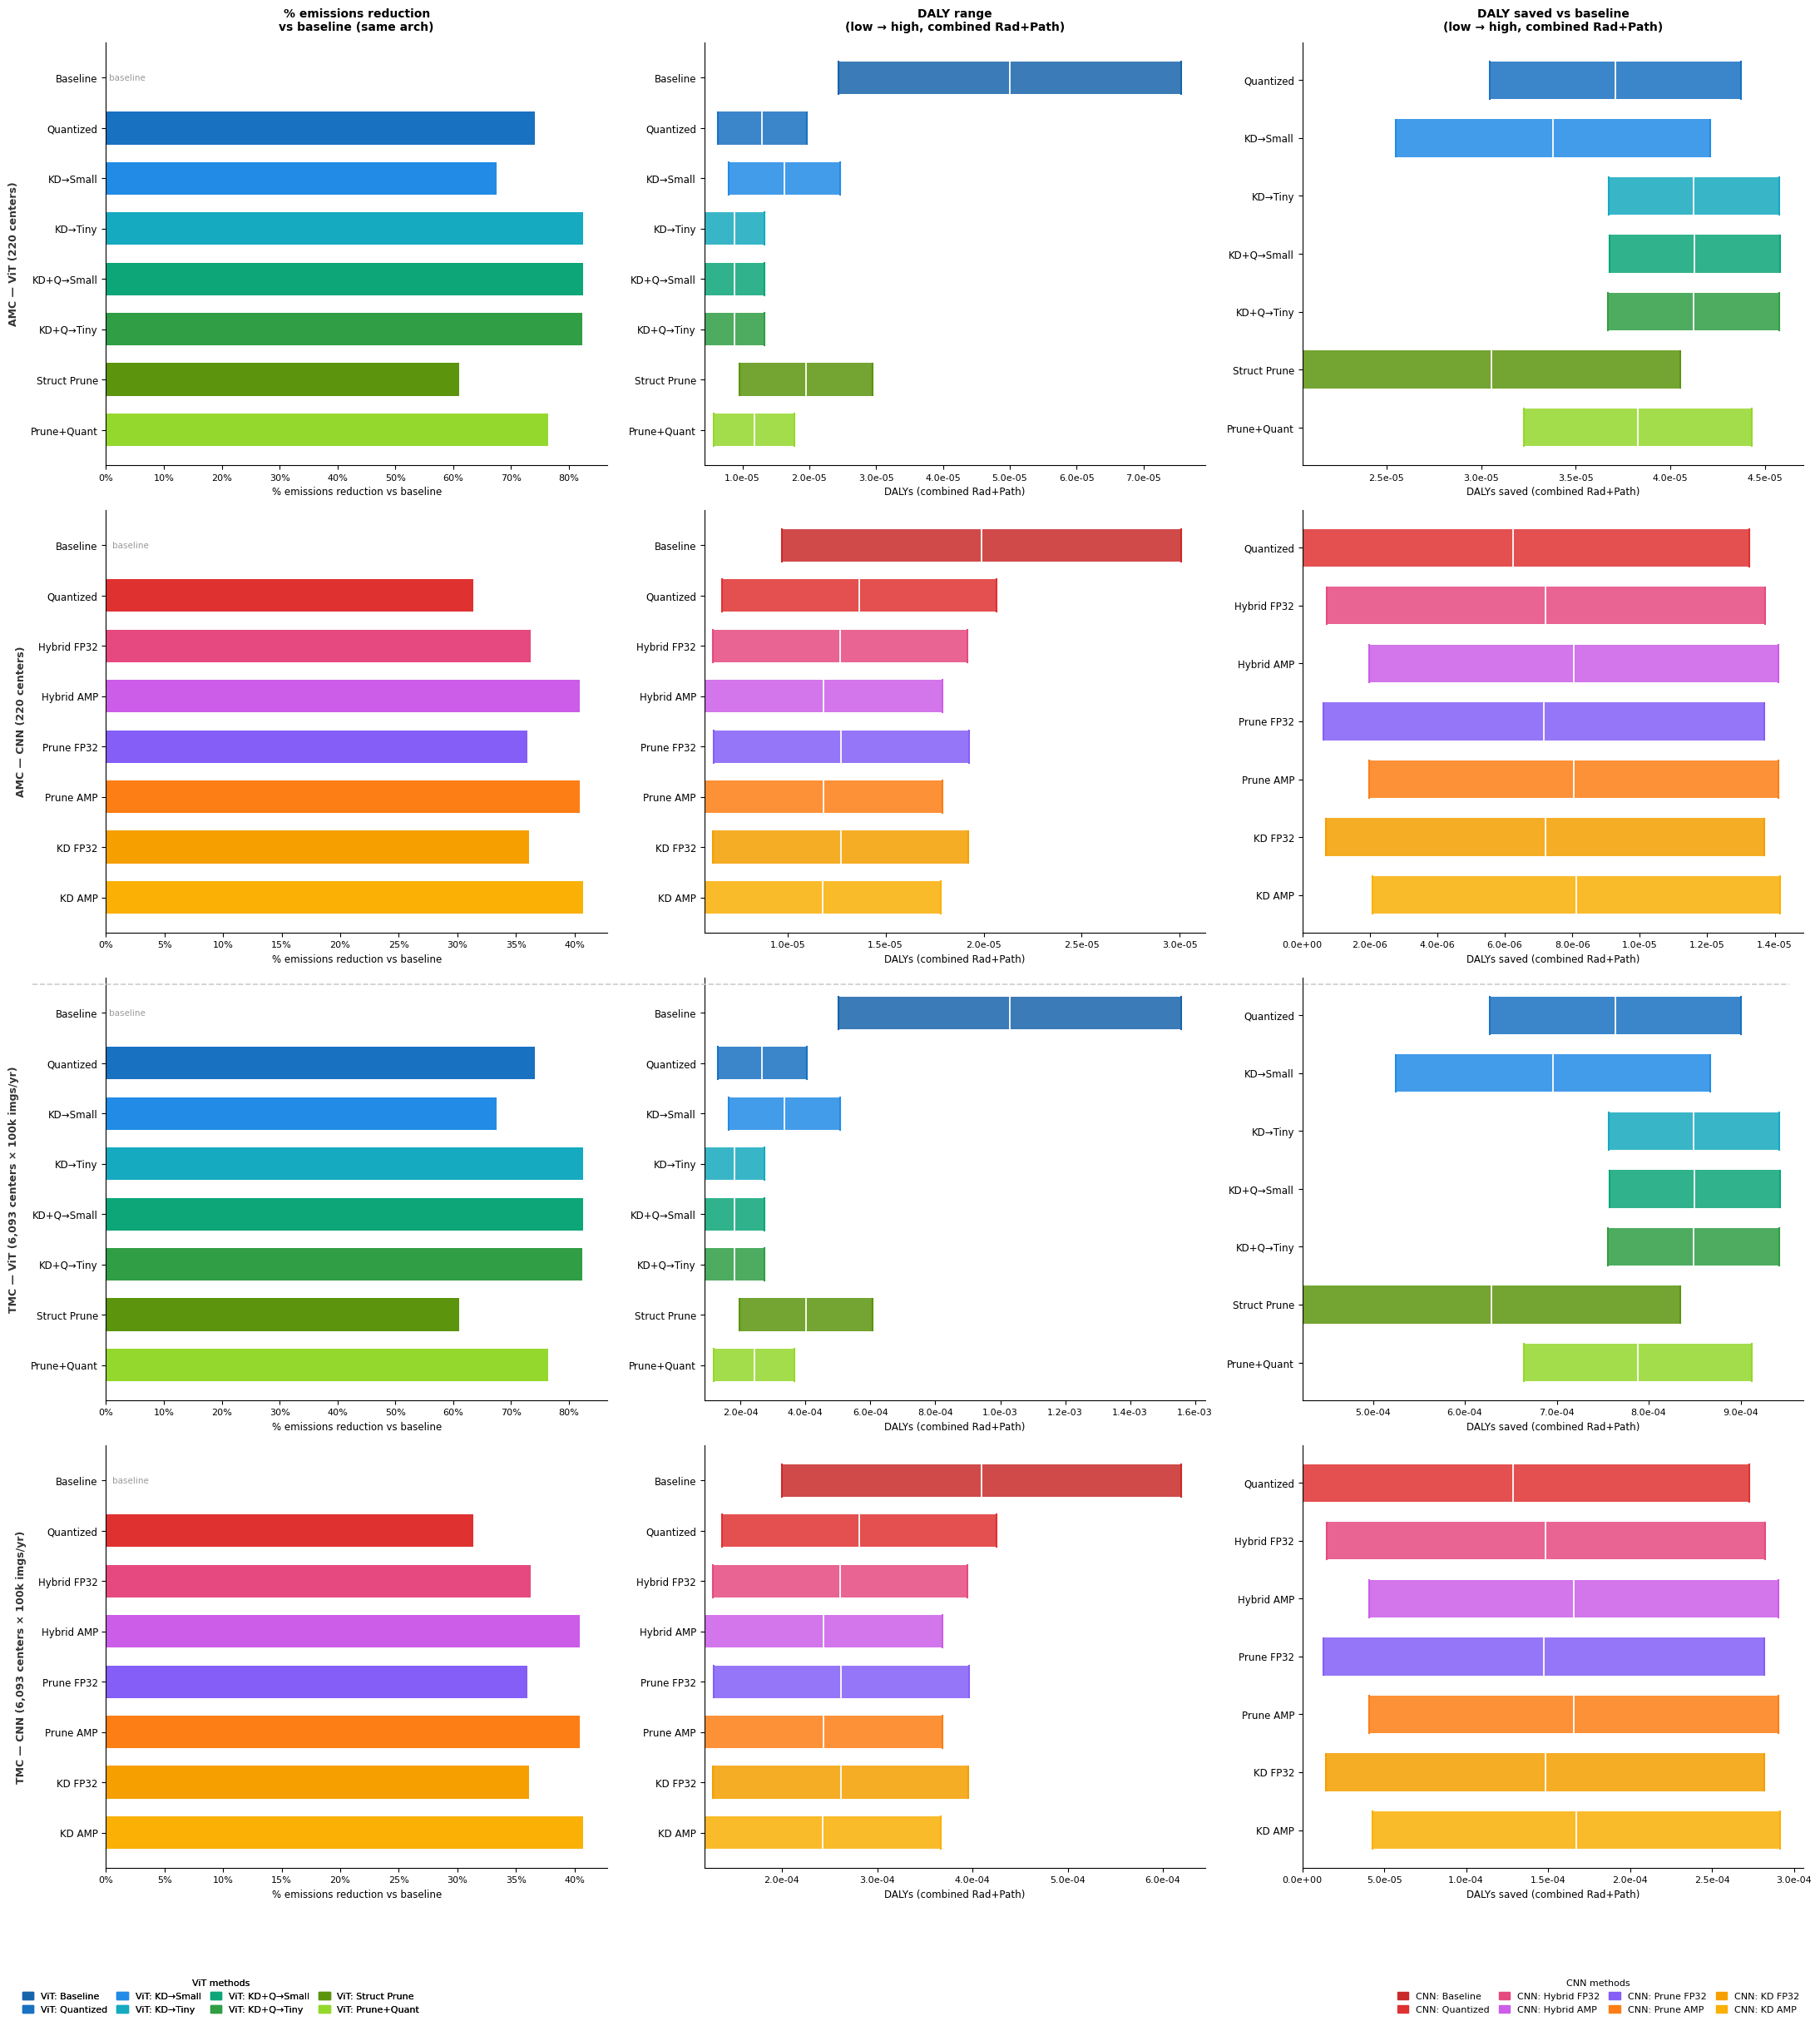

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# ── Data ───────────────────────────────────────────────────────────────────────
# arch, method, co2, rad_low, rad_high, path_low, path_high, pct_reduction
data = [
    ("ViT", "Baseline (Base)",           2.0625e-7, 4.90838e-8, 1.5216e-7,  6.1875e-8,  1.91813e-7, None),
    ("ViT", "Quantized (Base)",          5.3425e-8, 1.27142e-8, 3.9414e-8,  1.60275e-8, 4.96853e-8, 0.740969697),
    ("ViT", "KD (Base→Small)",           6.6925e-8, 1.59269e-8, 4.93735e-8, 2.00775e-8, 6.22403e-8, 0.675515152),
    ("ViT", "KD (Base→Tiny)",            3.63e-8,   8.63875e-9, 2.67801e-8, 1.089e-8,   3.3759e-8,  0.824),
    ("ViT", "KD+Quant (Base→Small)",     3.61e-8,   8.59115e-9, 2.66326e-8, 1.083e-8,   3.3573e-8,  0.824969697),
    ("ViT", "KD+Quant (Base→Tiny)",      3.635e-8,  8.65065e-9, 2.6817e-8,  1.0905e-8,  3.38055e-8, 0.823757576),
    ("ViT", "Struct Pruning (Base)",     8.0375e-8, 1.91278e-8, 5.92962e-8, 2.41125e-8, 7.47488e-8, 0.61030303),
    ("ViT", "Struct Pruning+Quant",      4.8525e-8, 1.15481e-8, 3.5799e-8,  1.45575e-8, 4.51283e-8, 0.764727273),
    ("CNN", "Baseline (FP32)",           8.2e-8,    1.95145e-8, 6.0495e-8,  2.46e-8,    7.626e-8,   None),
    ("CNN", "Quantized (AMP)",           5.625e-8,  1.33865e-8, 4.14981e-8, 1.6875e-8,  5.23125e-8, 0.31402439),
    ("CNN", "Hybrid 50% (FP32)",         5.2275e-8, 1.24405e-8, 3.85656e-8, 1.56825e-8, 4.86158e-8, 0.3625),
    ("CNN", "Hybrid 50% (AMP)",          4.8825e-8, 1.16195e-8, 3.60204e-8, 1.46475e-8, 4.54073e-8, 0.404573171),
    ("CNN", "Struct Pruning 50% (FP32)", 5.25e-8,   1.24941e-8, 3.87316e-8, 1.575e-8,   4.8825e-8,  0.359756098),
    ("CNN", "Struct Pruning 50% (AMP)",  4.88e-8,   1.16135e-8, 3.60019e-8, 1.464e-8,   4.5384e-8,  0.404878049),
    ("CNN", "KD 50% (FP32)",             5.235e-8,  1.24584e-8, 3.86209e-8, 1.5705e-8,  4.86855e-8, 0.361585366),
    ("CNN", "KD 50% (AMP)",              4.8575e-8, 1.156e-8,   3.58359e-8, 1.45725e-8, 4.51748e-8, 0.407621951),
]

# ── Volumes ────────────────────────────────────────────────────────────────────
BASE_RAD_IMGS  = 1_189_910
BASE_PATH_IMGS = 1_500_000
AMC_RAD  = BASE_RAD_IMGS  * 220
AMC_PATH = BASE_PATH_IMGS * 220
TMC_RAD  = 100_000 * 10 * 6_093
TMC_PATH = 100_000 * 10 * 6_093

# ── Build rows ─────────────────────────────────────────────────────────────────
rows = []
for arch, method, co2, rl, rh, pl, ph, pct in data:
    rows.append(dict(
        arch=arch, method=method, co2=co2,
        rl=rl / BASE_RAD_IMGS,
        rh=rh / BASE_RAD_IMGS,
        pl=pl / BASE_PATH_IMGS,
        ph=ph / BASE_PATH_IMGS,
        pct=pct,
    ))

vit_rows = [r for r in rows if r['arch'] == 'ViT']
cnn_rows = [r for r in rows if r['arch'] == 'CNN']

# ── Colors — separate palettes per arch ───────────────────────────────────────
# ViT: blues/teals/greens (cool)
VIT_COLORS = ['#1864AB','#1971C2','#228BE6','#15AABF','#0CA678','#2F9E44','#5C940D','#94D82D']
# CNN: reds/oranges/purples/warm (warm)
CNN_COLORS = ['#C92A2A','#E03131','#E64980','#CC5DE8','#845EF7','#FD7E14','#F59F00','#FAB005']

short_vit = ["Baseline","Quantized","KD→Small","KD→Tiny","KD+Q→Small","KD+Q→Tiny","Struct Prune","Prune+Quant"]
short_cnn = ["Baseline","Quantized","Hybrid FP32","Hybrid AMP","Prune FP32","Prune AMP","KD FP32","KD AMP"]

# ── Helpers ────────────────────────────────────────────────────────────────────
def combined(row, rad_vol, path_vol):
    low  = row['rl'] * rad_vol + row['pl'] * path_vol
    high = row['rh'] * rad_vol + row['ph'] * path_vol
    return low, (low + high) / 2, high

def saved_range(arch_rows, rad_vol, path_vol):
    """(lo, mid, hi) DALYs saved vs arch baseline. Skips baseline row."""
    base = next(r for r in arch_rows if r['pct'] is None)
    _, base_mid, _ = combined(base, rad_vol, path_vol)
    out = []
    for r in arch_rows:
        if r['pct'] is None:
            continue
        lo, mid, hi = combined(r, rad_vol, path_vol)
        out.append((max(base_mid - hi,  0),
                    max(base_mid - mid, 0),
                    max(base_mid - lo,  0)))
    return out

sci     = FuncFormatter(lambda x, _: f"{x:.1e}")
pct_fmt = FuncFormatter(lambda x, _: f"{x*100:.0f}%")

def style_ax(ax, xlabel, ylabels):
    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=8.5)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.invert_yaxis()

def draw_pct(ax, arch_rows, colors, short_lbs, xlabel):
    y = np.arange(len(arch_rows))
    pct_vals = [r['pct'] if r['pct'] is not None else 0.0 for r in arch_rows]
    ax.barh(y, pct_vals, color=colors, edgecolor='none', height=0.65)
    for i, r in enumerate(arch_rows):
        if r['pct'] is None:
            ax.text(0.005, i, 'baseline', fontsize=7.5, color='#999', va='center')
    ax.xaxis.set_major_formatter(pct_fmt)
    style_ax(ax, xlabel, short_lbs)

def draw_floating(ax, triples, colors, ylabels, xlabel):
    for i, (lo, mid, hi) in enumerate(triples):
        ax.barh(i, hi - lo, left=lo, color=colors[i], edgecolor='none', height=0.65, alpha=0.85)
        ax.plot([lo,  lo],  [i-0.32, i+0.32], color=colors[i], lw=1.5)
        ax.plot([hi,  hi],  [i-0.32, i+0.32], color=colors[i], lw=1.5)
        ax.plot([mid, mid], [i-0.32, i+0.32], color='white',    lw=1.3)
    ax.xaxis.set_major_formatter(sci)
    style_ax(ax, xlabel, ylabels)

# ── Figure layout: 4 rows × 3 cols ────────────────────────────────────────────
# Row 0: ViT AMC  |  Row 1: CNN AMC  |  Row 2: ViT TMC  |  Row 3: CNN TMC
SCENARIOS = [
    (AMC_RAD, AMC_PATH, "ViT", vit_rows, VIT_COLORS, short_vit, "AMC — ViT (220 centers)"),
    (AMC_RAD, AMC_PATH, "CNN", cnn_rows, CNN_COLORS, short_cnn, "AMC — CNN (220 centers)"),
    (TMC_RAD, TMC_PATH, "ViT", vit_rows, VIT_COLORS, short_vit, "TMC — ViT (6,093 centers × 100k imgs/yr)"),
    (TMC_RAD, TMC_PATH, "CNN", cnn_rows, CNN_COLORS, short_cnn, "TMC — CNN (6,093 centers × 100k imgs/yr)"),
]

COL_TITLES = [
    "% emissions reduction\nvs baseline (same arch)",
    "DALY range\n(low → high, combined Rad+Path)",
    "DALY saved vs baseline\n(low → high, combined Rad+Path)",
]

# Height per row proportional to number of bars (8 each)
fig, axes = plt.subplots(4, 3, figsize=(22, 24))
fig.patch.set_facecolor('white')

for ri, (rad_vol, path_vol, arch, arch_rows, colors, short_lbs, row_label) in enumerate(SCENARIOS):
    n = len(arch_rows)
    non_base = [r for r in arch_rows if r['pct'] is not None]
    nb_colors = [colors[i] for i, r in enumerate(arch_rows) if r['pct'] is not None]
    nb_labels = [s for s, r in zip(short_lbs, arch_rows) if r['pct'] is not None]

    # Col 0: % emissions reduction
    draw_pct(axes[ri, 0], arch_rows, colors, short_lbs,
             "% emissions reduction vs baseline")

    # Col 1: DALY range (all rows including baseline)
    triples = [combined(r, rad_vol, path_vol) for r in arch_rows]
    draw_floating(axes[ri, 1], triples, colors, short_lbs,
                  "DALYs (combined Rad+Path)")

    # Col 2: DALY saved (non-baseline rows only)
    nb_triples = saved_range(arch_rows, rad_vol, path_vol)
    draw_floating(axes[ri, 2], nb_triples, nb_colors, nb_labels,
                  "DALYs saved (combined Rad+Path)")

    # Row label on left y-axis of col 0
    axes[ri, 0].set_ylabel(row_label, fontsize=9, fontweight='bold',
                           rotation=90, labelpad=10, color='#333')

# ── Column titles (top row only) ──────────────────────────────────────────────
for ci, title in enumerate(COL_TITLES):
    axes[0, ci].set_title(title, fontsize=10, fontweight='bold', pad=10)

# ── Divider lines between scenario pairs (between row 1 and 2) ────────────────
# Drawn as a horizontal line spanning the figure
fig.add_artist(plt.Line2D([0.02, 0.98], [0.505, 0.505],
               transform=fig.transFigure, color='#ccc', lw=1.2, ls='--'))

# ── Legends — one per arch ────────────────────────────────────────────────────
vit_patches = [mpatches.Patch(color=VIT_COLORS[i], label=f"ViT: {short_vit[i]}")
               for i in range(len(vit_rows))]
cnn_patches = [mpatches.Patch(color=CNN_COLORS[i], label=f"CNN: {short_cnn[i]}")
               for i in range(len(cnn_rows))]

leg1 = fig.legend(handles=vit_patches, loc='lower left',
                  ncol=4, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.01, -0.015),
                  handlelength=1.2, handleheight=0.9, columnspacing=1.0,
                  title='ViT methods', title_fontsize=8)
leg2 = fig.legend(handles=cnn_patches, loc='lower right',
                  ncol=4, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.99, -0.015),
                  handlelength=1.2, handleheight=0.9, columnspacing=1.0,
                  title='CNN methods', title_fontsize=8)
fig.add_artist(leg1)

plt.tight_layout(rect=[0, 0.04, 1, 1.0])
plt.savefig('/Users/arihangupta/Downloads/pruning_project_data/PruneAndTrain/daly_charts.png', dpi=180, bbox_inches='tight',
            facecolor='white')
print("Saved.")